In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from common import plotting
from common.config import Params, SUPERMODEL_PERTURBATIONS, results_dir
from common.data import add_noise, sample_collocation, sample_measurements
from common.model import pde_snapshots
from common.pinn import PINN
from common.supermodels import make_supermodel_params, supermodel_ode_system, train_supernet
from common.surrogates import solve_surrogate_ode

OUT = results_dir("zad7")

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

TRUE_PARAMS = Params(D=0.02, p=0.05, q=4.0)
T_END = 5.0
NX = 150
DT = 5e-4
NOISE_LEVEL = 0.05
NOISE_KIND = "gaussian_mixture"
PROC_SIGMA = 0.02
COUPLING_STRENGTH = 2.0
N_DATA = 400
N_COLLOCATION = 6000
EPOCHS = 2000
LAMBDA_COUPLE = 0.5


Using device: cpu


In [2]:
x_true, t_true, u_true_clean = pde_snapshots(TRUE_PARAMS, T_END, NX, DT, init_kind="localized", save_every=10)
u_true_noisy = add_noise(u_true_clean, NOISE_KIND, NOISE_LEVEL, np.random.default_rng(321))
u_true_mean = np.mean(u_true_clean, axis=0)
print(f"PDE data generated: {u_true_clean.shape}, noisy: {u_true_noisy.shape}")


PDE data generated: (150, 1001), noisy: (150, 1001)


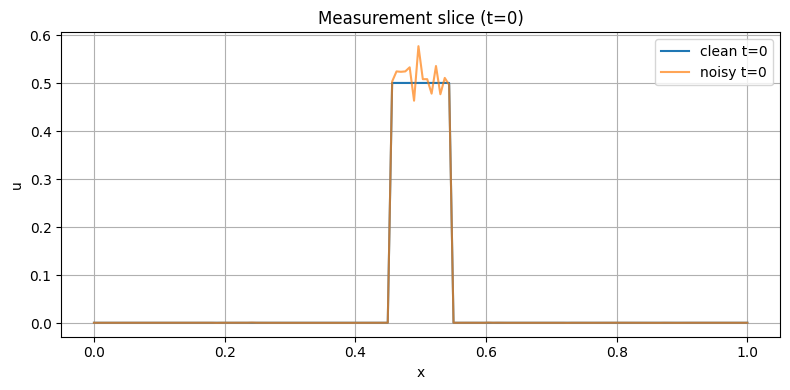

In [3]:
plotting.plot_noise_slice(x_true, u_true_clean, u_true_noisy, OUT / "zad7_noise_slice_t0.png")

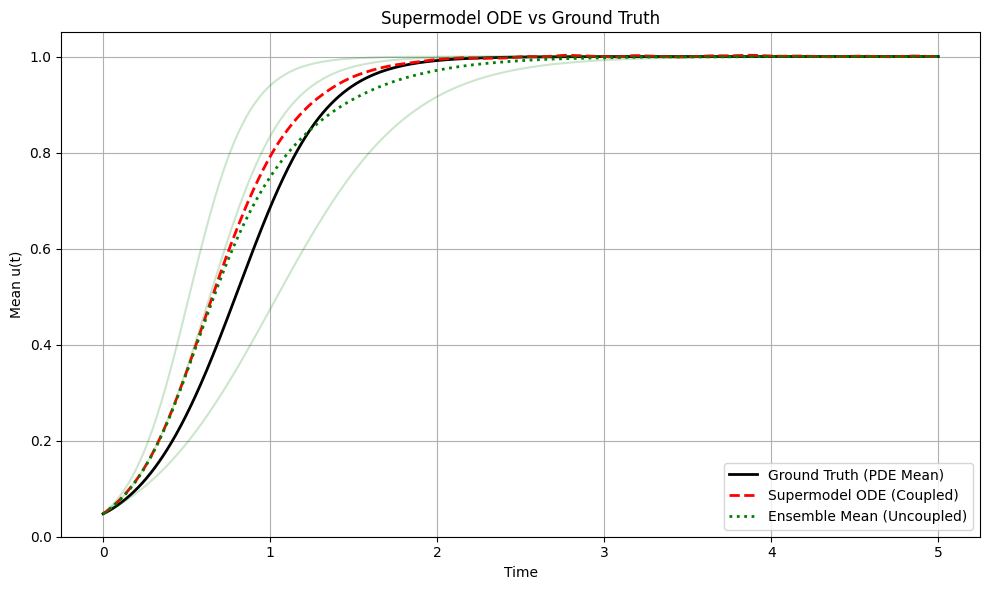

In [4]:
members = make_supermodel_params(TRUE_PARAMS, SUPERMODEL_PERTURBATIONS)
proc_noise_paths = np.random.normal(0.0, PROC_SIGMA, size=(len(members), len(t_true)))
y0 = [u_true_mean[0]] * len(members)

sol_super = solve_ivp(
    lambda t, y: supermodel_ode_system(t, y, members, COUPLING_STRENGTH, proc_noise_paths, t_true),
    [t_true[0], t_true[-1]], y0, t_eval=t_true,
)
u_super_mean = np.mean(sol_super.y, axis=0)

u_indep_all = []
for params in members:
    sol = solve_surrogate_ode(params.p, params.q, float(u_true_mean[0]), [t_true[0], t_true[-1]], t_eval=t_true)
    u_indep_all.append(sol.y.flatten())
u_indep_all = np.asarray(u_indep_all)

plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, "k-", linewidth=2, label="Ground Truth (PDE Mean)")
plt.plot(t_true, u_super_mean, "r--", linewidth=2, label="Supermodel ODE (Coupled)")
plt.plot(t_true, np.mean(u_indep_all, axis=0), "g:", linewidth=2, label="Ensemble Mean (Uncoupled)")
for i in range(3):
    plt.plot(t_true, u_indep_all[i], "g-", alpha=0.2)
plt.legend()
plt.title("Supermodel ODE vs Ground Truth")
plt.xlabel("Time")
plt.ylabel("Mean u(t)")
plt.grid(True)
plotting.savefig(OUT / "supermodel_ode_results.png", dpi=150)
plt.show()


Epoch 500/2000, Total Loss: 0.179930, lambda_couple=0.499, LR=9.00e-04
Epoch 1000/2000, Total Loss: 0.057985, lambda_couple=0.500, LR=8.10e-04
Epoch 1500/2000, Total Loss: 0.039569, lambda_couple=0.500, LR=7.29e-04
Epoch 2000/2000, Total Loss: 0.169681, lambda_couple=0.500, LR=6.56e-04
Training finished in 156.08s


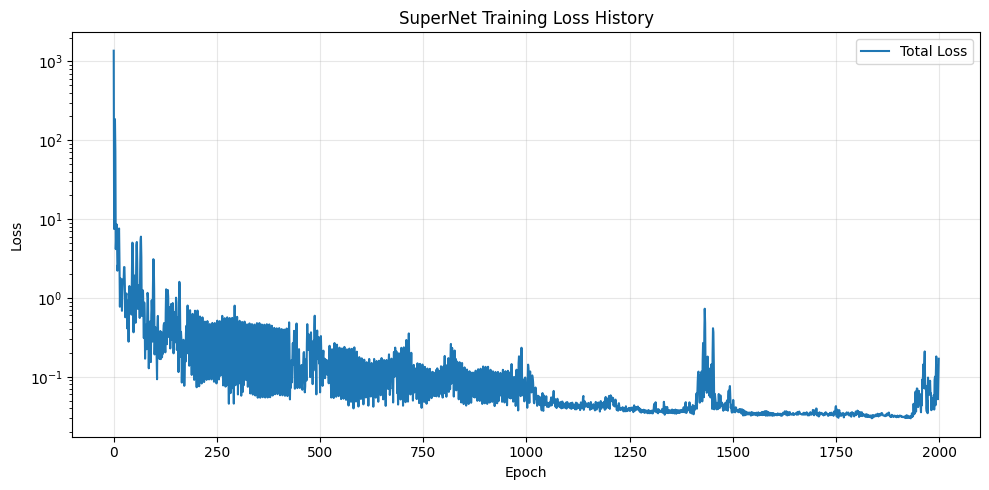

In [5]:
X_u_train, u_train = sample_measurements(x_true, t_true, u_true_noisy, N_DATA, np.random.default_rng(777))
X_f_train = sample_collocation(N_COLLOCATION, T_END, np.random.default_rng(888))

X_u_train_t = torch.tensor(X_u_train, dtype=torch.float32).to(DEVICE)
u_train_t = torch.tensor(u_train, dtype=torch.float32).to(DEVICE)
X_f_train_t = torch.tensor(X_f_train, dtype=torch.float32).to(DEVICE)

models = [PINN(hidden_dim=64, num_layers=5, use_residual=True).to(DEVICE) for _ in range(3)]
history, train_time = train_supernet(
    models,
    X_u_train_t[:, 0:1], X_u_train_t[:, 1:2], u_train_t,
    X_f_train_t[:, 0:1], X_f_train_t[:, 1:2],
    members, TRUE_PARAMS.D,
    epochs=EPOCHS,
    lambda_couple_final=LAMBDA_COUPLE,
)
print(f"Training finished in {train_time:.2f}s")

loss_arr = np.asarray(history)
plt.figure(figsize=(10, 5))
plt.plot(loss_arr[:, 0], linewidth=1.5, label="Total Loss")
plt.yscale("log")
plt.title("SuperNet Training Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plotting.savefig(OUT / "supernet_loss_history_improved.png", dpi=150)
plt.show()


SuperModel ODE     MAE: 0.022180 RMSE: 0.045112
SuperNet PINN      MAE: 0.010666 RMSE: 0.012541
Single ODE         MAE: 0.054936 RMSE: 0.111640


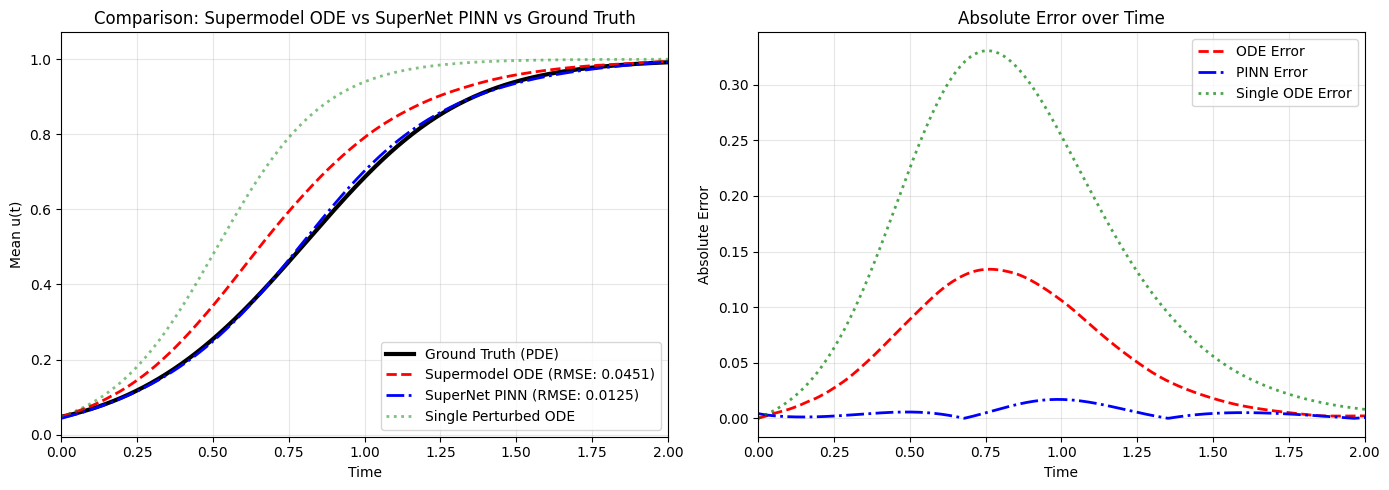

In [6]:
X_grid, T_grid = np.meshgrid(x_true, t_true)
x_eval = torch.tensor(X_grid.flatten()[:, None], dtype=torch.float32).to(DEVICE)
t_eval = torch.tensor(T_grid.flatten()[:, None], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    preds = [m(x_eval, t_eval).cpu().numpy() for m in models]
u_supernet_mean = np.mean(np.asarray(preds), axis=0).reshape(X_grid.shape).mean(axis=1)

rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
mae = lambda a, b: float(np.mean(np.abs(a - b)))
rmse_ode, mae_ode = rmse(u_true_mean, u_super_mean), mae(u_true_mean, u_super_mean)
rmse_pinn, mae_pinn = rmse(u_true_mean, u_supernet_mean), mae(u_true_mean, u_supernet_mean)
rmse_single, mae_single = rmse(u_true_mean, u_indep_all[0]), mae(u_true_mean, u_indep_all[0])

print(f"SuperModel ODE     MAE: {mae_ode:.6f} RMSE: {rmse_ode:.6f}")
print(f"SuperNet PINN      MAE: {mae_pinn:.6f} RMSE: {rmse_pinn:.6f}")
print(f"Single ODE         MAE: {mae_single:.6f} RMSE: {rmse_single:.6f}")

(OUT / "supernet_metrics.txt").write_text(
    f"SuperModel ODE - MAE: {mae_ode:.6f}, RMSE: {rmse_ode:.6f}\n"
    f"SuperNet PINN - MAE: {mae_pinn:.6f}, RMSE: {rmse_pinn:.6f}\n"
    f"Single Perturbed ODE - MAE: {mae_single:.6f}, RMSE: {rmse_single:.6f}\n"
    f"Training time: {train_time:.2f}s\n"
    f"Network: 64 hidden units, 5 layers with residual connections\n"
    f"Epochs: {EPOCHS}\n"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_true, u_true_mean, "k-", linewidth=3, label="Ground Truth (PDE)")
axes[0].plot(t_true, u_super_mean, "r--", linewidth=2, label=f"Supermodel ODE (RMSE: {rmse_ode:.4f})")
axes[0].plot(t_true, u_supernet_mean, "b-.", linewidth=2, label=f"SuperNet PINN (RMSE: {rmse_pinn:.4f})")
axes[0].plot(t_true, u_indep_all[0], "g:", alpha=0.5, linewidth=2, label="Single Perturbed ODE")
axes[0].set_title("Comparison: Supermodel ODE vs SuperNet PINN vs Ground Truth")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mean u(t)")
axes[0].set_xlim(0, 2)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_true, np.abs(u_true_mean - u_super_mean), "r--", linewidth=2, label="ODE Error")
axes[1].plot(t_true, np.abs(u_true_mean - u_supernet_mean), "b-.", linewidth=2, label="PINN Error")
axes[1].plot(t_true, np.abs(u_true_mean - u_indep_all[0]), "g:", alpha=0.7, linewidth=2, label="Single ODE Error")
axes[1].set_title("Absolute Error over Time")
axes[1].set_xlabel("Time")
axes[1].set_xlim(0, 2)
axes[1].set_ylabel("Absolute Error")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plotting.savefig(OUT / "supermodel_vs_supernet_improved.png", dpi=150)
plt.show()
